# ZARA Fashion Sales Analysis
## Seasonal & Demographic Insights (2018–2025)
**ITCS 227 – Introduction to Data Science | Capstone Project**

---
### Research Questions
1. Which fashion categories sell best in each season?
2. Do different age groups have different purchasing preferences?
3. Are there gender-based differences in product preference?
4. How do season and demographic factors interact to drive sales?

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load & Inspect Data

In [2]:
# Load dataset
df = pd.read_excel('fashion_new_data2.xlsx')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Dataset Shape: (2640, 19)
Rows: 2,640 | Columns: 19


,product_id,product_name,gender,category,pattern,color,age_group,season,price,material,sales_count,reviews_count,average_rating,out_of_stock_times,brand,discount,wish_list_count,month_of_sale,year_of_sale
0,1001,Biker Jacket,Male,Shirt,Geometric,White,25-35,Spring,70.36,Synthetic,75,65,4.9,3,ZARA,0.20,211,1,2018
1,1002,Business Shirt,Male,Jacket,Polka Dots,Beige,18-24,Summer,91.59,Wool,296,25,3.5,6,ZARA,0.00,211,1,2018
2,1003,Wool Jacket,Female,Dress,Geometric,Brown,18-24,All,129.52,Wool,50,32,4.3,4,ZARA,0.05,64,1,2018
3,1004,Summer Dress,Male,Shorts,Plain,White,25-35,All,116.01,Cotton,435,73,4.6,3,ZARA,0.10,171,1,2018
4,1005,Casual Jeans,Male,Shirt,Plain,Beige,35-45,Winter,125.48,Viscose,79,36,3.6,4,ZARA,0.00,126,1,2018


In [3]:
# Data types and basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          2640 non-null   int64  
 1   product_name        2640 non-null   str    
 2   gender              2640 non-null   str    
 3   category            2640 non-null   str    
 4   pattern             2640 non-null   str    
 5   color               2640 non-null   str    
 6   age_group           2640 non-null   str    
 7   season              2640 non-null   str    
 8   price               2640 non-null   float64
 9   material            2640 non-null   str    
 10  sales_count         2640 non-null   int64  
 11  reviews_count       2640 non-null   int64  
 12  average_rating      2640 non-null   float64
 13  out_of_stock_times  2640 non-null   int64  
 14  brand               2640 non-null   str    
 15  discount            2640 non-null   float64
 16  wish_list_count  

In [4]:
# Statistical summary of numeric columns
df.describe().round(2)

,product_id,price,sales_count,reviews_count,average_rating,out_of_stock_times,discount,wish_list_count,month_of_sale,year_of_sale
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,1330.50,84.97,274.99,62.16,4.02,3.53,0.10,151.68,6.50,2023.00
std,190.56,37.60,138.50,23.55,0.55,1.70,0.07,57.40,3.45,2.00
min,1001.00,20.25,45.00,20.00,3.00,1.00,0.00,50.00,1.00,2018.00
25%,1165.75,53.20,154.00,42.00,3.60,2.00,0.05,99.00,3.75,2022.75
50%,1330.50,82.04,269.00,63.00,4.00,4.00,0.10,151.00,6.50,2023.50
75%,1495.25,117.77,388.00,83.25,4.50,5.00,0.15,203.00,9.25,2024.25
max,1660.00,149.93,587.00,100.00,5.00,6.00,0.20,250.00,12.00,2025.00


## 3. Data Cleaning & Preprocessing

In [5]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

Missing values per column:
No missing values found!


In [6]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

# Unique values of categorical columns
cat_cols = ['gender', 'category', 'age_group', 'season', 'brand']
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')

Duplicate rows: 0
gender: ['Male', 'Female']
category: ['Shirt', 'Jacket', 'Dress', 'Shorts', 'Blouse', 'Shoes', 'Jeans', 'Skirt']
age_group: ['25-35', '18-24', '35-45']
season: ['Spring', 'Summer', 'All', 'Winter', 'Autumn']
brand: ['ZARA']


In [7]:
# Define ordered categories for consistent plotting
SEASON_ORDER = ['Spring', 'Summer', 'Autumn', 'Winter', 'All']
AGE_ORDER    = ['18-24', '25-35', '35-45']
COLORS       = ['#E8A0BF', '#BA90C6', '#C0DBEA', '#8EC5FC', '#F5CBA7']

# Convert to ordered categorical
df['season']    = pd.Categorical(df['season'],    categories=SEASON_ORDER, ordered=True)
df['age_group'] = pd.Categorical(df['age_group'], categories=AGE_ORDER,    ordered=True)

print('Preprocessing complete!')
print(f'Year range: {df["year_of_sale"].min()} – {df["year_of_sale"].max()}')
print(f'Price range: ${df["price"].min():.2f} – ${df["price"].max():.2f}')

Preprocessing complete!
Year range: 2018 – 2025
Price range: $20.25 – $149.93


## 4. Exploratory Data Analysis (EDA)

### 4.1 Overall Sales Distribution

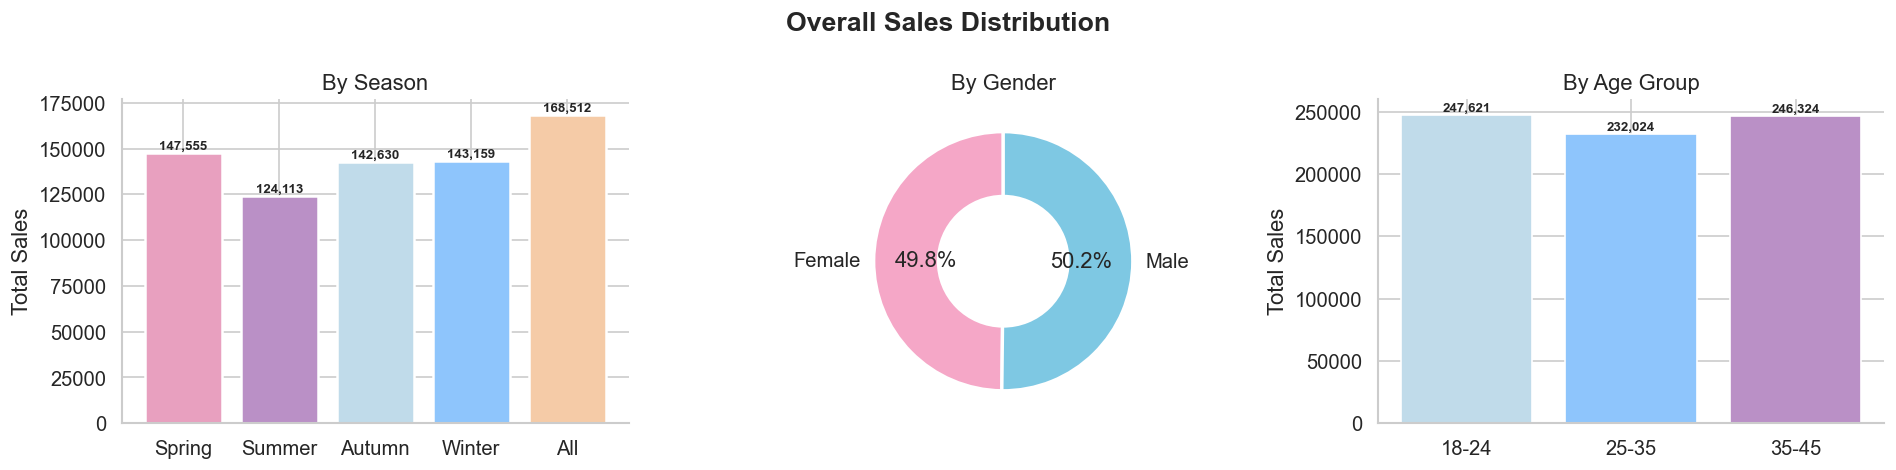

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Overall Sales Distribution', fontsize=16, fontweight='bold')

# By Season
season_sales = df.groupby('season', observed=True)['sales_count'].sum()
bars = axes[0].bar(season_sales.index, season_sales.values, color=COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title('By Season')
axes[0].set_ylabel('Total Sales')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# By Gender
gender_sales = df.groupby('gender')['sales_count'].sum()
axes[1].pie(gender_sales.values, labels=gender_sales.index,
            autopct='%1.1f%%', colors=['#F5A7C7', '#7EC8E3'],
            wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
            startangle=90)
axes[1].set_title('By Gender')

# By Age Group
age_sales = df.groupby('age_group', observed=True)['sales_count'].sum()
bars2 = axes[2].bar(age_sales.index, age_sales.values, color=['#C0DBEA','#8EC5FC','#BA90C6'], edgecolor='white')
axes[2].set_title('By Age Group')
axes[2].set_ylabel('Total Sales')
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2 Category Sales Overview

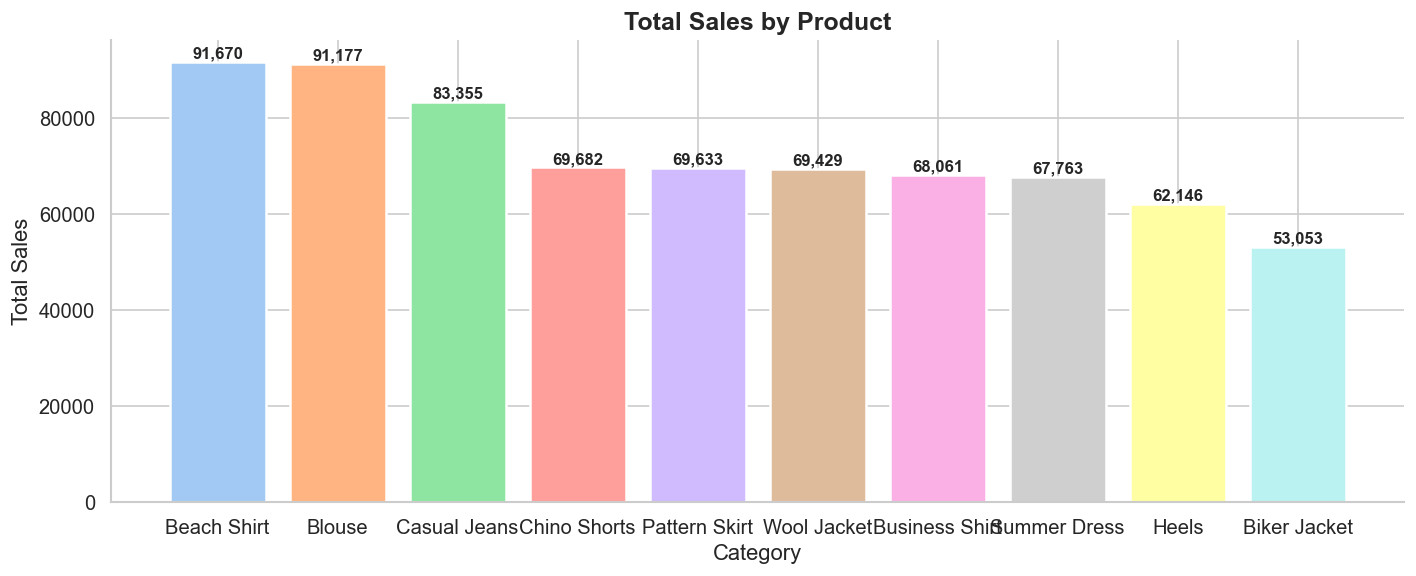

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

cat_sales = df.groupby('product_name')['sales_count'].sum().sort_values(ascending=False)
palette = sns.color_palette('pastel', len(cat_sales))
bars = ax.bar(cat_sales.index, cat_sales.values, color=palette, edgecolor='white', linewidth=1.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Total Sales by Product', fontsize=15, fontweight='bold')
ax.set_ylabel('Total Sales')
ax.set_xlabel('Category')
plt.tight_layout()
plt.show()

## 5. Seasonal Analysis

### 5.1 Best-Selling Category per Season

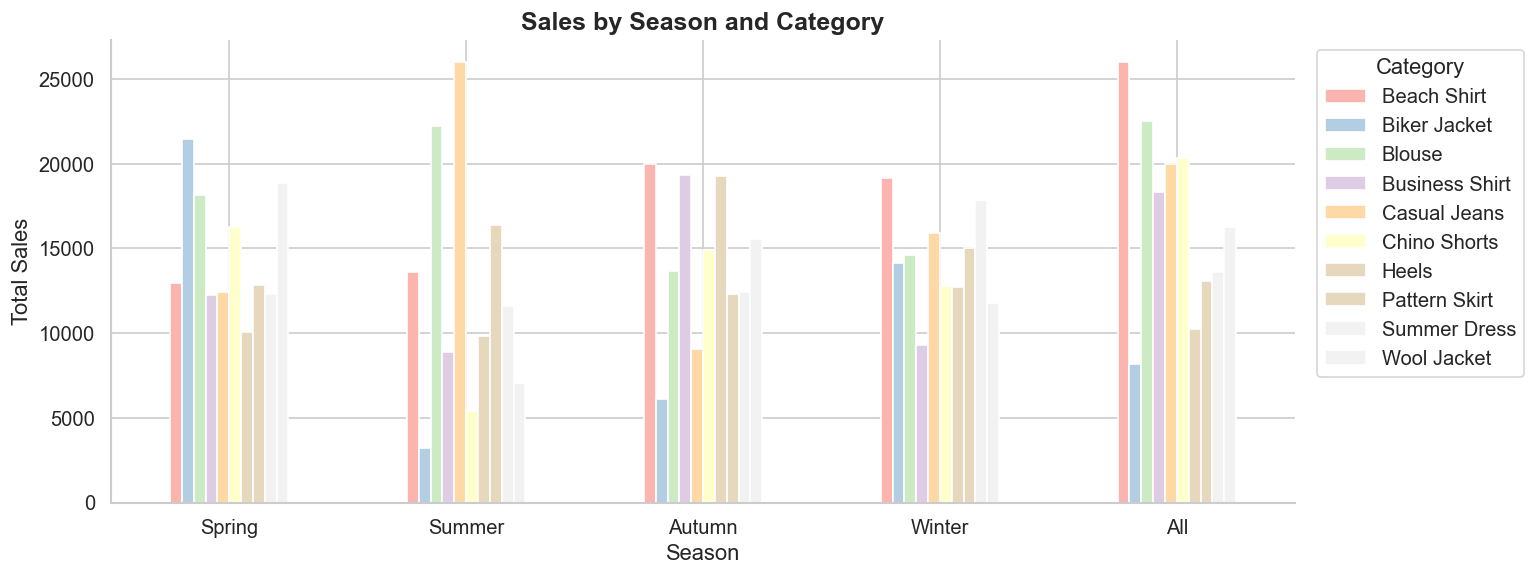


Best-Selling Category per Season:
  Spring   → Biker Jacket (21,457)
  Summer   → Casual Jeans (26,019)
  Autumn   → Beach Shirt (19,951)
  Winter   → Beach Shirt (19,166)
  All      → Beach Shirt (25,979)


In [10]:
season_cat = df.groupby(['season', 'product_name'], observed=True)['sales_count'].sum().unstack()

fig, ax = plt.subplots(figsize=(13, 5))
season_cat.plot(kind='bar', ax=ax, colormap='Pastel1', edgecolor='white', linewidth=1)

ax.set_title('Sales by Season and Category', fontsize=15, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Total Sales')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Summary table
print('\nBest-Selling Category per Season:')
for s in SEASON_ORDER:
    top = season_cat.loc[s].idxmax()
    val = season_cat.loc[s].max()
    print(f'  {s:8s} → {top} ({val:,})')

### 5.2 Heatmap: Season × Category

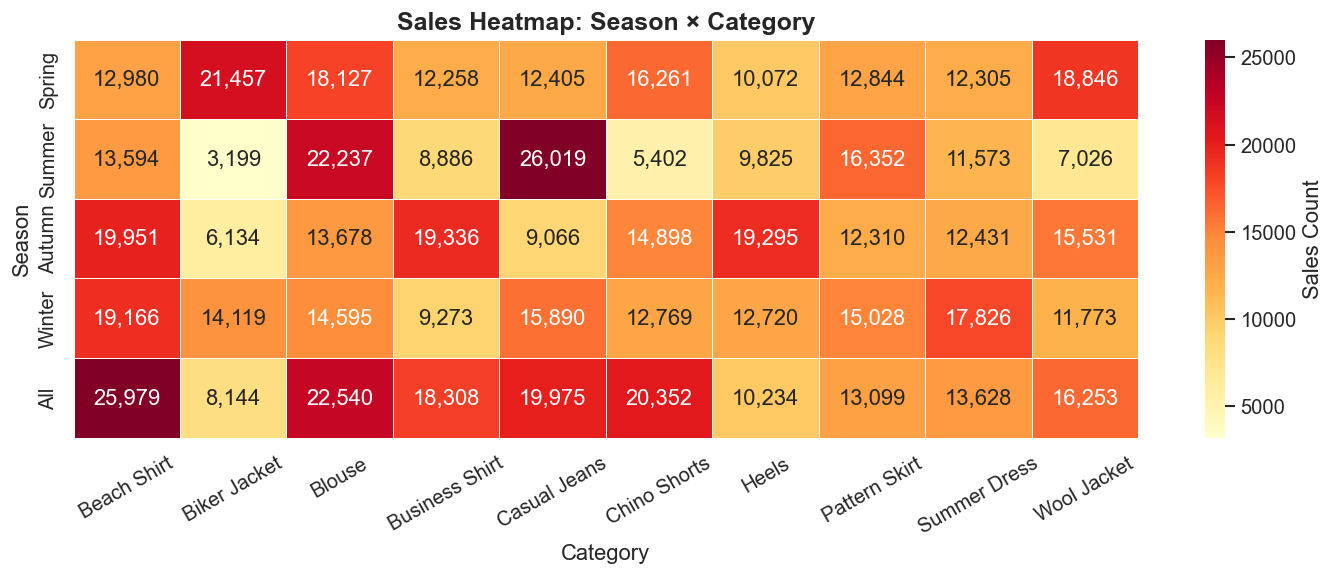

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(season_cat, ax=ax, cmap='YlOrRd', annot=True, fmt=',d',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Sales Count'})

ax.set_title('Sales Heatmap: Season × Category', fontsize=15, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Season')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 6. Gender Analysis

### 6.1 Category Preference by Gender

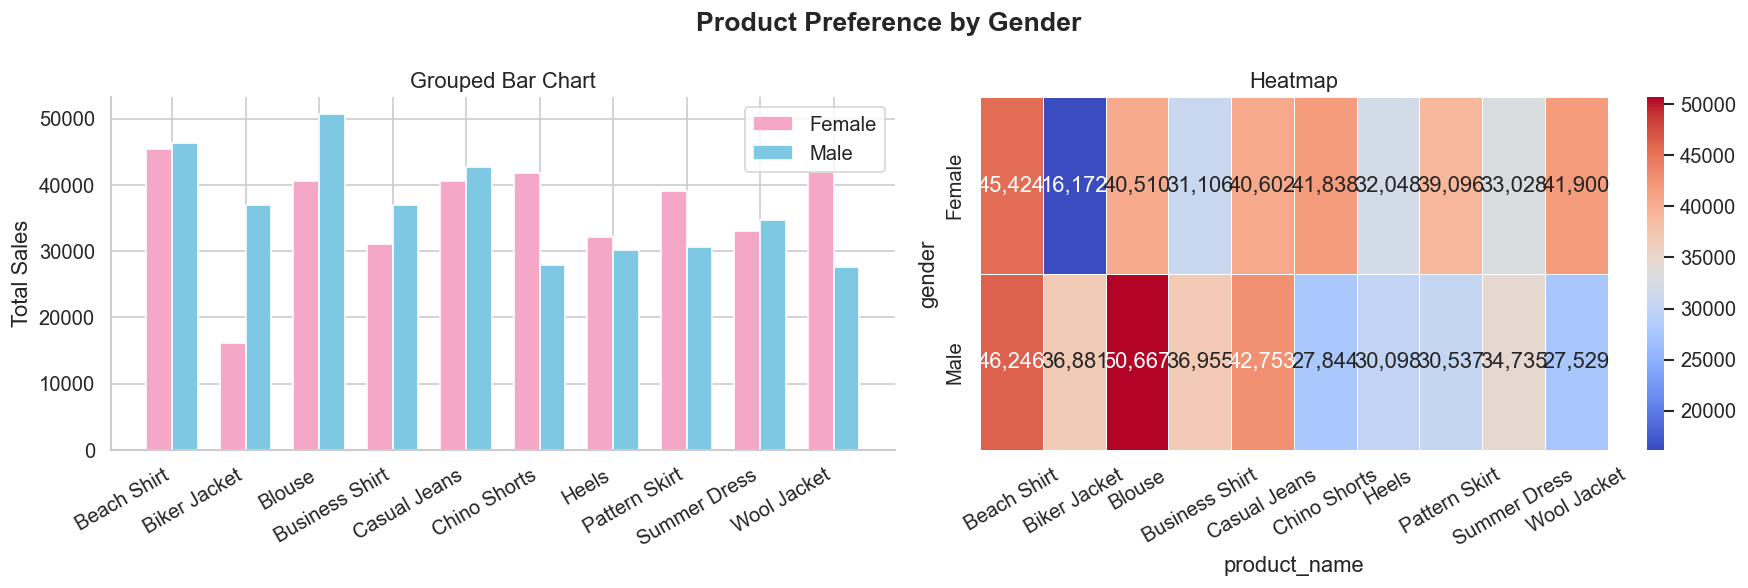

Top Product per Gender:
  Female: Beach Shirt (45,424)
  Male: Blouse (50,667)


In [12]:
gender_cat = df.groupby(['gender', 'product_name'])['sales_count'].sum().unstack()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Product Preference by Gender', fontsize=16, fontweight='bold')

# Grouped bar
x = np.arange(len(gender_cat.columns))
w = 0.35
axes[0].bar(x - w/2, gender_cat.loc['Female'], w, label='Female', color='#F5A7C7', edgecolor='white')
axes[0].bar(x + w/2, gender_cat.loc['Male'],   w, label='Male',   color='#7EC8E3', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(gender_cat.columns, rotation=30, ha='right')
axes[0].set_ylabel('Total Sales')
axes[0].set_title('Grouped Bar Chart')
axes[0].legend()

# Heatmap
sns.heatmap(gender_cat, ax=axes[1], cmap='coolwarm', annot=True, fmt=',d',
            linewidths=0.5, linecolor='white')
axes[1].set_title('Heatmap')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Top category per gender
print('Top Product per Gender:')
for g in ['Female', 'Male']:
    top = gender_cat.loc[g].idxmax()
    val = gender_cat.loc[g].max()
    print(f'  {g}: {top} ({val:,})')

### 6.2 Season × Gender Interaction

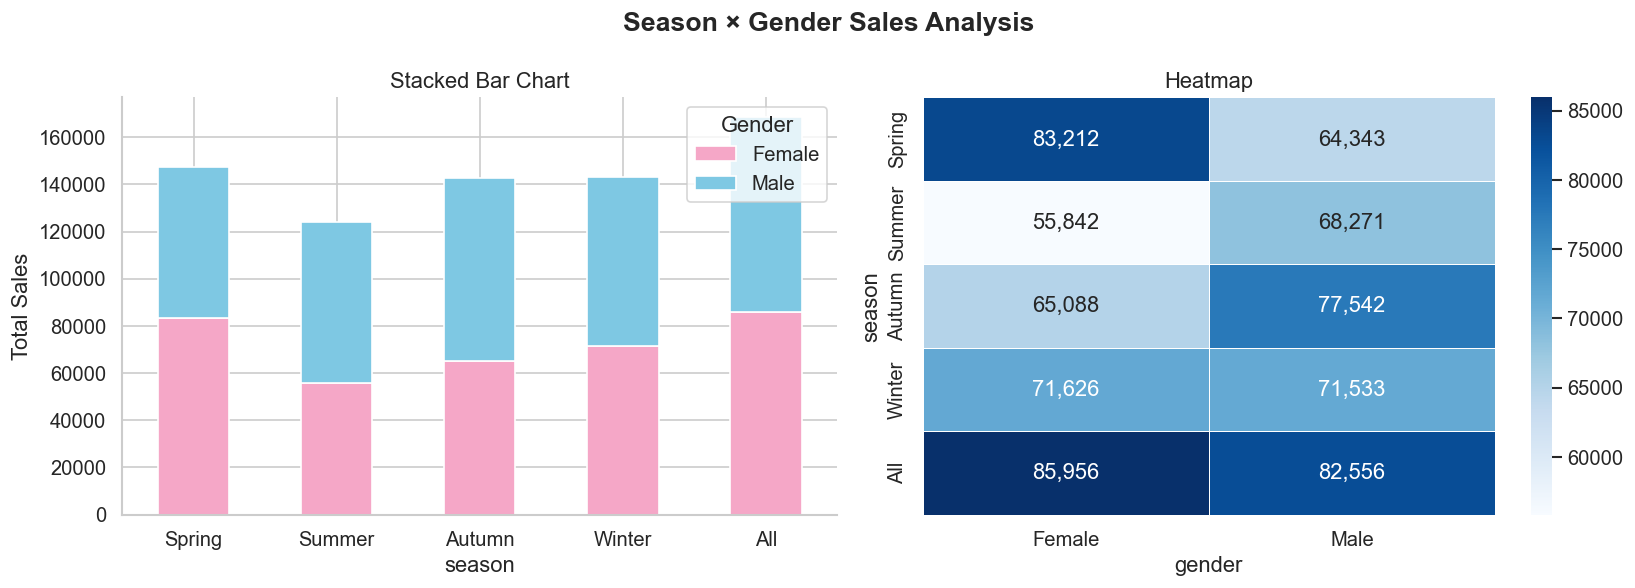

In [13]:
season_gender = df.groupby(['season', 'gender'], observed=True)['sales_count'].sum().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Season × Gender Sales Analysis', fontsize=16, fontweight='bold')

# Stacked bar
season_gender.plot(kind='bar', ax=axes[0], color=['#F5A7C7', '#7EC8E3'], edgecolor='white', stacked=True)
axes[0].set_title('Stacked Bar Chart')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylabel('Total Sales')
axes[0].legend(title='Gender')

# Heatmap
sns.heatmap(season_gender, ax=axes[1], cmap='Blues', annot=True, fmt=',d',
            linewidths=0.5, linecolor='white')
axes[1].set_title('Heatmap')

plt.tight_layout()
plt.show()

## 7. Age Group Analysis

### 7.1 Category Preference by Age Group

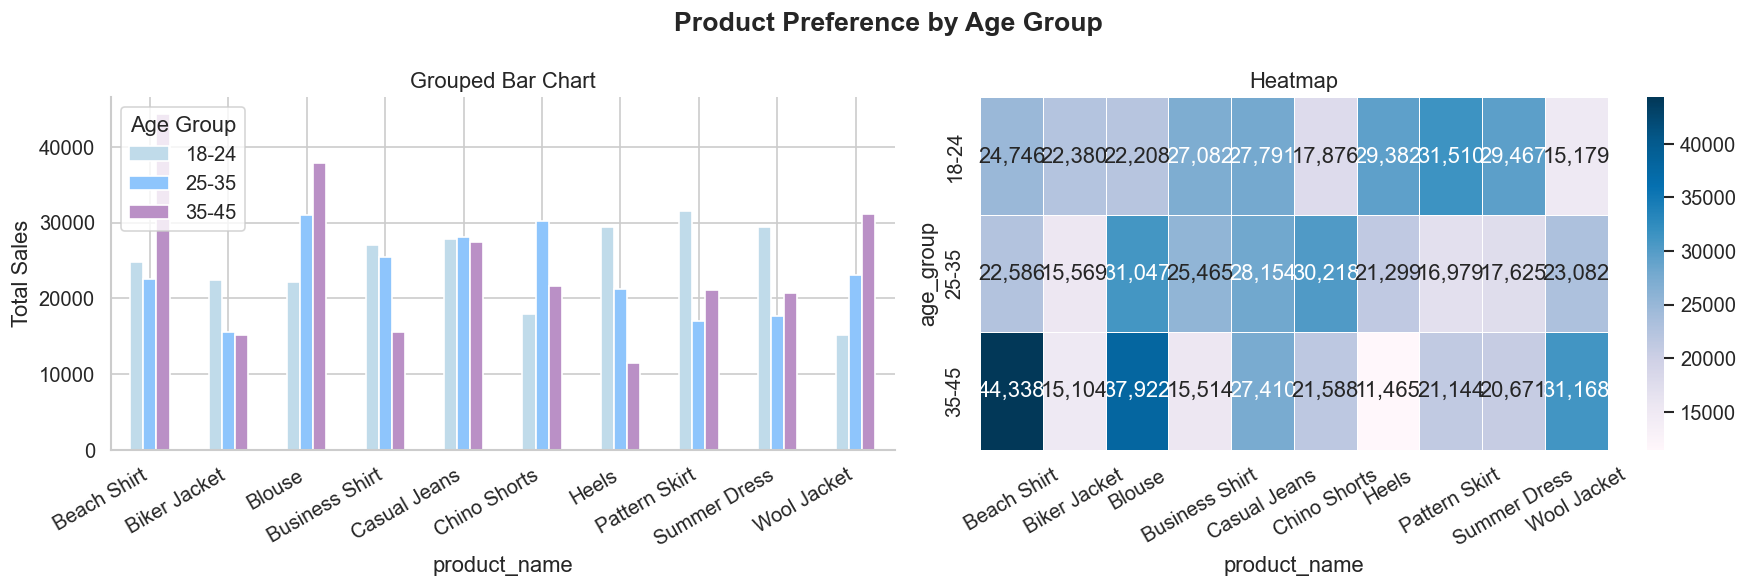

Top Product per Age Group:
  18-24: Pattern Skirt (31,510)
  25-35: Blouse (31,047)
  35-45: Beach Shirt (44,338)


In [14]:
age_cat = df.groupby(['age_group', 'product_name'], observed=True)['sales_count'].sum().unstack()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Product Preference by Age Group', fontsize=16, fontweight='bold')

# Grouped bar
age_cat.T.plot(kind='bar', ax=axes[0], color=['#C0DBEA', '#8EC5FC', '#BA90C6'], edgecolor='white')
axes[0].set_title('Grouped Bar Chart')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylabel('Total Sales')
axes[0].legend(title='Age Group')

# Heatmap
sns.heatmap(age_cat, ax=axes[1], cmap='PuBu', annot=True, fmt=',d',
            linewidths=0.5, linecolor='white')
axes[1].set_title('Heatmap')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Top category per age group
print('Top Product per Age Group:')
for age in AGE_ORDER:
    top = age_cat.loc[age].idxmax()
    val = age_cat.loc[age].max()
    print(f'  {age}: {top} ({val:,})')

### 7.2 Season × Age Group Interaction

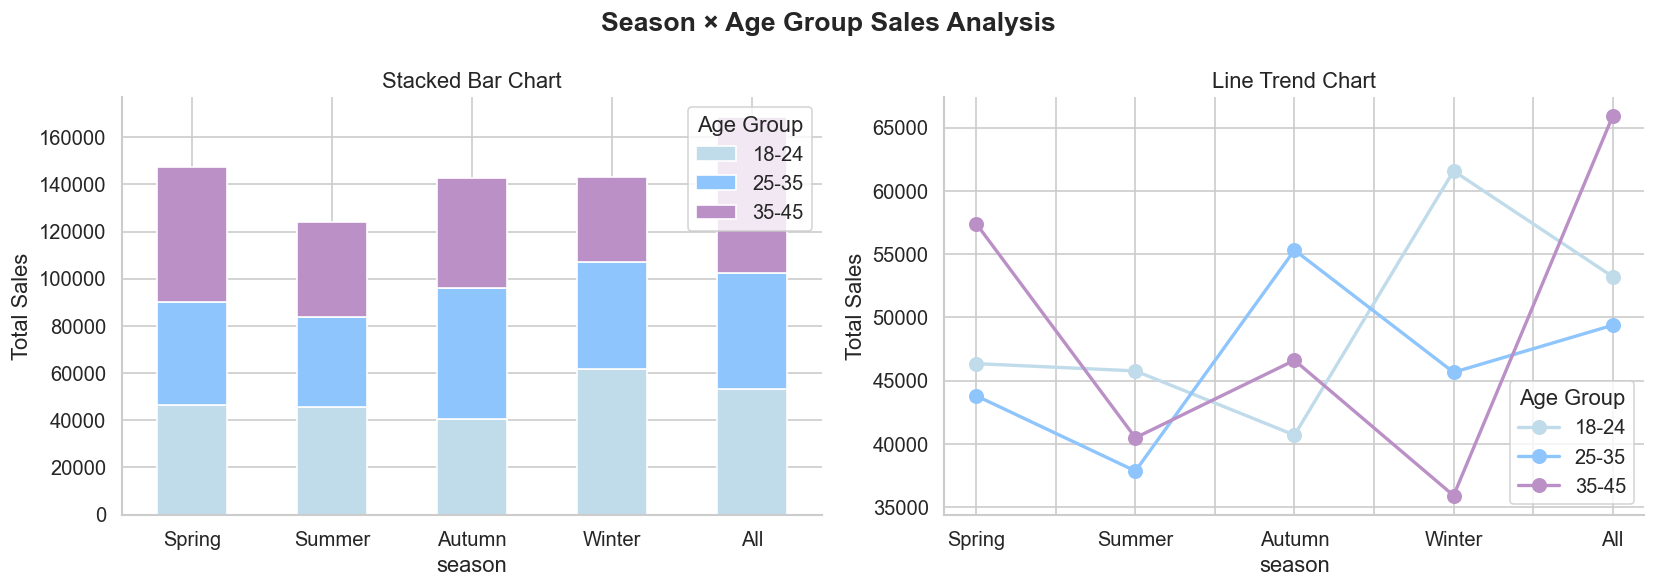

In [15]:
season_age = df.groupby(['season', 'age_group'], observed=True)['sales_count'].sum().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Season × Age Group Sales Analysis', fontsize=16, fontweight='bold')

# Stacked bar
season_age.plot(kind='bar', ax=axes[0], color=['#C0DBEA', '#8EC5FC', '#BA90C6'],
                edgecolor='white', stacked=True)
axes[0].set_title('Stacked Bar Chart')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylabel('Total Sales')
axes[0].legend(title='Age Group')

# Line chart for trend
season_age.plot(kind='line', ax=axes[1], color=['#C0DBEA', '#8EC5FC', '#BA90C6'],
                marker='o', linewidth=2, markersize=8)
axes[1].set_title('Line Trend Chart')
axes[1].set_ylabel('Total Sales')
axes[1].legend(title='Age Group')

plt.tight_layout()
plt.show()

## 8. Key Findings Summary

In [16]:
print('=' * 60)
print('KEY FINDINGS SUMMARY')
print('=' * 60)

print('\n[1] SEASONAL TRENDS')
for s in SEASON_ORDER:
    total = df[df['season'] == s]['sales_count'].sum()
    top   = df[df['season'] == s].groupby('product_name')['sales_count'].sum().idxmax()
    print(f'    {s:8s}: Total = {total:,} | Best category = {top}')

print('\n[2] GENDER PREFERENCES')
for g in ['Female', 'Male']:
    total = df[df['gender'] == g]['sales_count'].sum()
    top   = df[df['gender'] == g].groupby('product_name')['sales_count'].sum().idxmax()
    print(f'    {g:8s}: Total = {total:,} | Favourite = {top}')

print('\n[3] AGE GROUP PREFERENCES')
for age in AGE_ORDER:
    total = df[df['age_group'] == age]['sales_count'].sum()
    top   = df[df['age_group'] == age].groupby('product_name')['sales_count'].sum().idxmax()
    print(f'    {age:8s}: Total = {total:,} | Favourite = {top}')

print('\n[4] TOP SEASON × GENDER COMBINATIONS')
sg = df.groupby(['season', 'gender'], observed=True)['sales_count'].sum().reset_index()
top3 = sg.nlargest(3, 'sales_count')
for _, row in top3.iterrows():
    print(f'    {row["season"]} × {row["gender"]}: {row["sales_count"]:,}')

print('\n' + '=' * 60)

KEY FINDINGS SUMMARY

[1] SEASONAL TRENDS
    Spring  : Total = 147,555 | Best category = Biker Jacket
    Summer  : Total = 124,113 | Best category = Casual Jeans
    Autumn  : Total = 142,630 | Best category = Beach Shirt
    Winter  : Total = 143,159 | Best category = Beach Shirt
    All     : Total = 168,512 | Best category = Beach Shirt

[2] GENDER PREFERENCES
    Female  : Total = 361,724 | Favourite = Beach Shirt
    Male    : Total = 364,245 | Favourite = Blouse

[3] AGE GROUP PREFERENCES
    18-24   : Total = 247,621 | Favourite = Pattern Skirt
    25-35   : Total = 232,024 | Favourite = Blouse
    35-45   : Total = 246,324 | Favourite = Beach Shirt

[4] TOP SEASON × GENDER COMBINATIONS
    All × Female: 85,956
    Spring × Female: 83,212
    All × Male: 82,556

